# Clustering de Breast Cancer Wisconsin con K-means + PCA
## Uso de framework de aprendizaje máquina (scikit-learn)

Este notebook contiene el analisis exploratorio, la reduccion de
dimensionalidad con PCA, el entrenamiento de K-means y la evaluacion
de resultados.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from kmeans_pca import (
    cargar_datos,
    alinear_clusters_con_etiquetas,
    aplicar_mapeo,
)

sns.set_style("whitegrid")


## 1. Carga de datos

In [2]:
X, y, nombres_clase = cargar_datos()

# armar un DataFrame solo para el EDA (mas comodo para graficar)
from sklearn.datasets import load_breast_cancer
datos_completos = load_breast_cancer()
df = pd.DataFrame(X, columns=datos_completos.feature_names)
df['target'] = y
df['diagnostico'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(df.shape)
df.head()


(569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 2. Analisis exploratorio (EDA)

diagnostico
benign       357
malignant    212
Name: count, dtype: int64

Proporcion:
diagnostico
benign       0.627
malignant    0.373
Name: proportion, dtype: float64


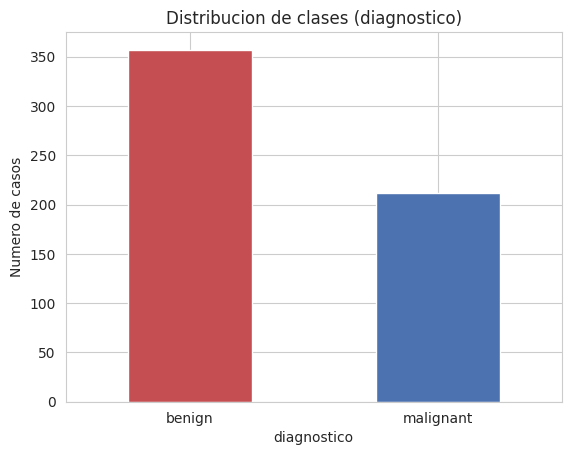

In [3]:
conteo = df['diagnostico'].value_counts()
print(conteo)
print('\nProporcion:')
print(df['diagnostico'].value_counts(normalize=True).round(3))

conteo.plot(kind='bar', color=['#C44E52', '#4C72B0'])
plt.title('Distribucion de clases (diagnostico)')
plt.ylabel('Numero de casos')
plt.xticks(rotation=0)
plt.show()


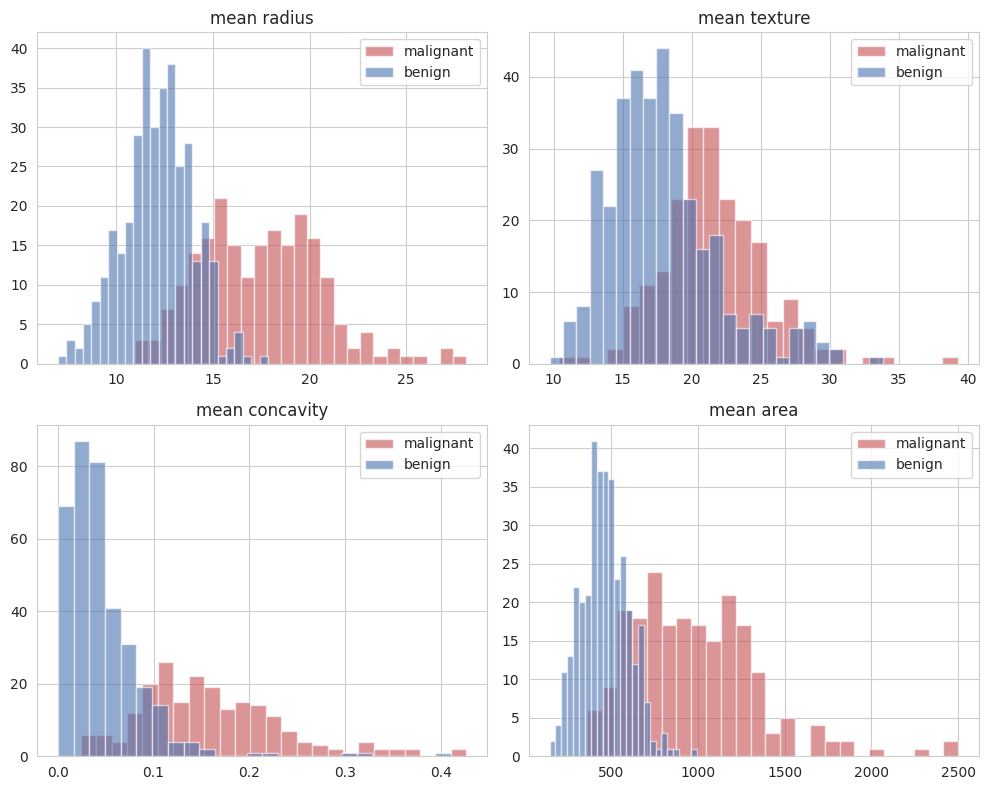

In [4]:
# Distribucion de algunas features clave, separadas por clase
features_interes = ['mean radius', 'mean texture', 'mean concavity', 'mean area']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feature in zip(axes.flat, features_interes):
    for clase, color in zip(['malignant', 'benign'], ['#C44E52', '#4C72B0']):
        subset = df[df['diagnostico'] == clase][feature]
        ax.hist(subset, bins=25, alpha=0.6, label=clase, color=color)
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()


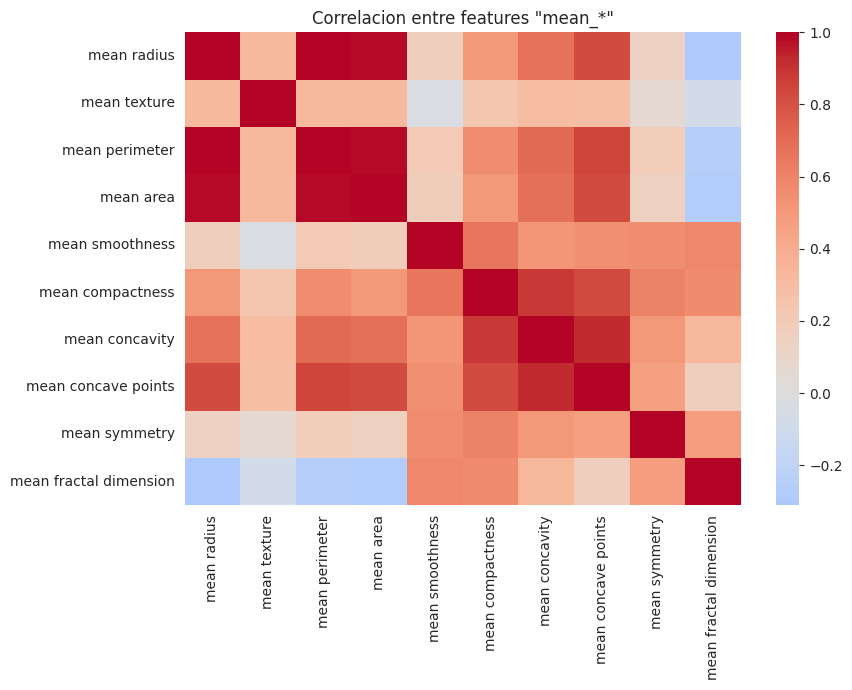

In [5]:
# Matriz de correlacion de las primeras 10 features (mean_*)
features_mean = [c for c in df.columns if c.startswith('mean')]
plt.figure(figsize=(9, 7))
sns.heatmap(df[features_mean].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlacion entre features "mean_*"')
plt.tight_layout()
plt.show()


## 3. Train / test split y escalado

80% entrenamiento / 20% prueba, estratificado por diagnostico. El
escalado (`StandardScaler`) es indispensable antes de PCA y K-means,
ya que ambos se basan en distancias y features con rangos mas grandes
(como `mean area`) dominarian el resultado si no se normalizan.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)

print('Train:', X_train_esc.shape, ' Test:', X_test_esc.shape)


Train: (455, 30)  Test: (114, 30)


## 4. PCA - reduccion de dimensionalidad

Antes de fijar el numero de componentes en 2, se revisa cuanta
varianza explica cada componente principal, para justificar la
decision con evidencia y no solo "porque se necesitan 2 para graficar".


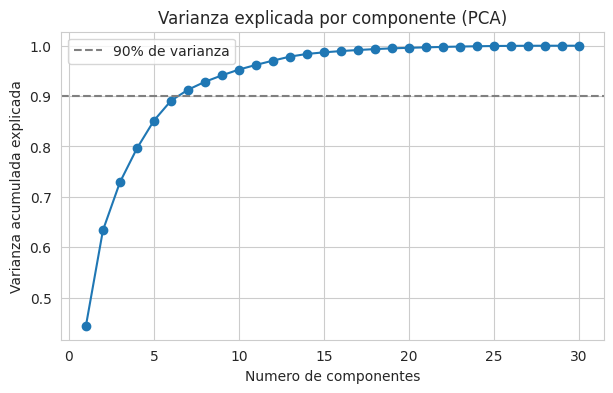

Varianza explicada con 2 componentes: 63.4%
Componentes necesarios para 90% de varianza: 7


In [7]:
pca_completo = PCA(random_state=42)
pca_completo.fit(X_train_esc)

varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(0.9, color='gray', linestyle='--', label='90% de varianza')
plt.xlabel('Numero de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('Varianza explicada por componente (PCA)')
plt.legend()
plt.show()

print(f'Varianza explicada con 2 componentes: {varianza_acumulada[1]:.1%}')
print(f'Componentes necesarios para 90% de varianza: {np.argmax(varianza_acumulada >= 0.9) + 1}')


In [8]:
# Se usan 2 componentes deliberadamente (aunque no alcancen el 90%)
# porque el objetivo es poder visualizar los clusters en un plano 2D,
# no maximizar la varianza explicada.
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_esc)
X_test_pca = pca.transform(X_test_esc)


## 5. Eleccion de k (metodo del codo)

Si bien, ya se conoce previamente que k = 2 (es el número de clases), se aplica el método del codo para comprobar viabilidad del método y darle sentido a la aplicación de K-Means


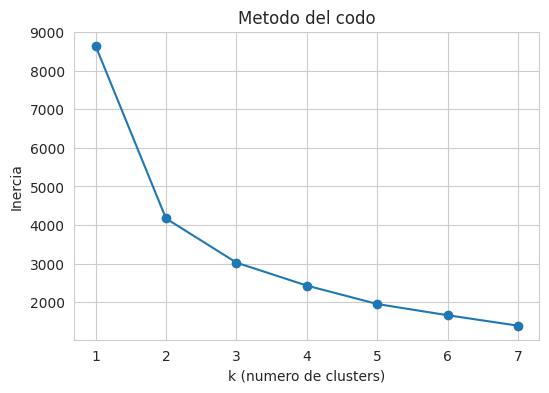

In [9]:
inercias = []
valores_k = range(1, 8)
for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_pca)
    inercias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(valores_k, inercias, marker='o')
plt.xlabel('k (numero de clusters)')
plt.ylabel('Inercia')
plt.title('Metodo del codo')
plt.show()


## 6. Entrenamiento de K-means (k=2)

In [10]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_train = kmeans.fit_predict(X_train_pca)
clusters_test = kmeans.predict(X_test_pca)

mapeo = alinear_clusters_con_etiquetas(clusters_train, y_train, n_clusters=2)
pred_train = aplicar_mapeo(clusters_train, mapeo)
pred_test = aplicar_mapeo(clusters_test, mapeo)

print('Mapeo cluster -> clase real:', mapeo)


Mapeo cluster -> clase real: {0: np.int64(1), 1: np.int64(0)}


## 7. Visualizacion: clases reales vs clusters encontrados

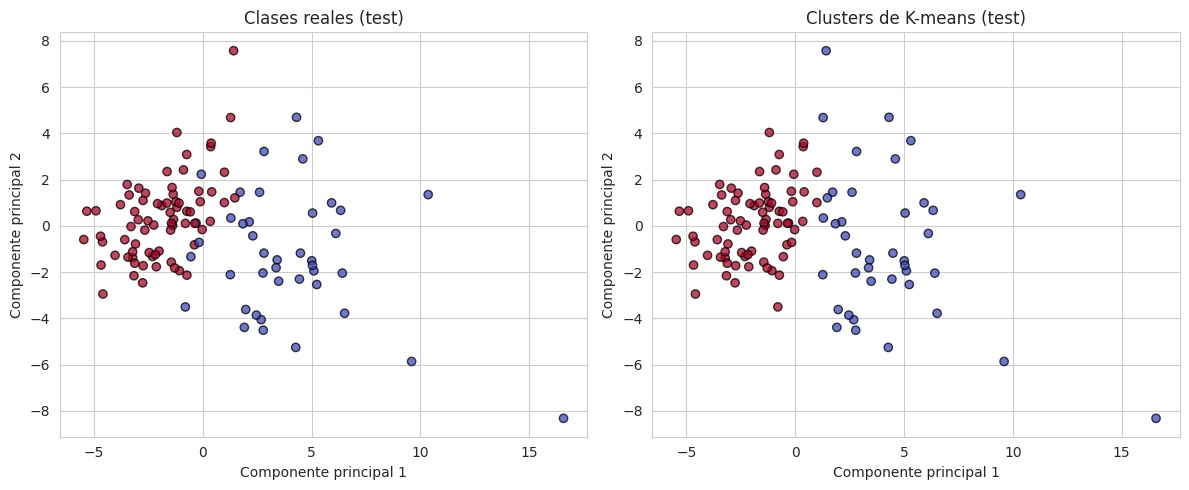

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc0 = axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', edgecolor='k', alpha=0.75)
axes[0].set_title('Clases reales (test)')
axes[0].set_xlabel('Componente principal 1')
axes[0].set_ylabel('Componente principal 2')

sc1 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=pred_test, cmap='coolwarm', edgecolor='k', alpha=0.75)
axes[1].set_title('Clusters de K-means (test)')
axes[1].set_xlabel('Componente principal 1')
axes[1].set_ylabel('Componente principal 2')

plt.tight_layout()
plt.show()


## 8. Matriz de confusion y metricas

In [12]:
def graficar_matriz_confusion(y_real, y_pred, titulo):
    matriz = confusion_matrix(y_real, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(matriz, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: malignant', 'Pred: benign'])
    ax.set_yticklabels(['Real: malignant', 'Real: benign'])
    ax.set_title(titulo)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matriz[i, j], ha='center', va='center', fontsize=13)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()
    return matriz


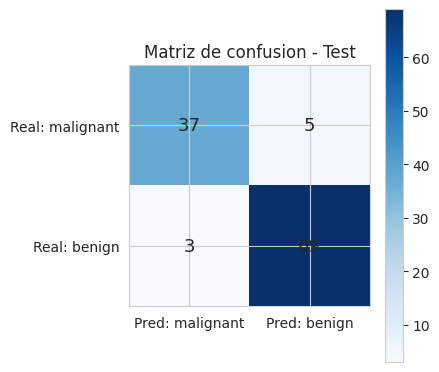

In [13]:
matriz_test = graficar_matriz_confusion(y_test, pred_test, 'Matriz de confusion - Test')


In [14]:
resultados = pd.DataFrame({
    'Entrenamiento': {
        'accuracy': accuracy_score(y_train, pred_train),
        'precision': precision_score(y_train, pred_train),
        'recall': recall_score(y_train, pred_train),
        'f1': f1_score(y_train, pred_train),
    },
    'Prueba': {
        'accuracy': accuracy_score(y_test, pred_test),
        'precision': precision_score(y_test, pred_test),
        'recall': recall_score(y_test, pred_test),
        'f1': f1_score(y_test, pred_test),
    },
})
resultados.round(3)


,Entrenamiento,Prueba
accuracy,0.901,0.930
precision,0.895,0.932
recall,0.954,0.958
f1,0.924,0.945
